# Traitement sitadel

In [1]:
!pip install -r requirements.txt

In [2]:
%run Sitadel2_traitement.py

/home/onyxia/work/projet3A/Sitadel2_traitement.py:22: DtypeWarning: Columns (0,2,4,7,11,17,19,20,21,23,29,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tmp, sep=";")
/home/onyxia/work/projet3A/Sitadel2_traitement.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["ANNEE_REELLE_AUTORISATION"] = pd.to_datetime(


Lancement de la requête BAN
df_ban
                                                 adresse    lat_BAN   lon_BAN  \
6923                       133 RUE LECOCQ 33000 BORDEAUX  44.833275 -0.588851   
8344                   181 RUE DE CHATILLON 35000 RENNES  48.088886 -1.672032   
25320              282 RUE FRANCOIS PERRIN 87000 LIMOGES  45.824679  1.227735   
602               606 BOULEVARD DU MERCANTOUR 06200 NICE  43.727756  7.185797   
23155              501 CHAUSSEE JULES FERRY 80090 AMIENS  49.877572  2.341606   
...                                                  ...        ...       ...   
25847   26 RUE HENRI-AUGUSTE-DESB 0<NA> CORBEIL ESSONNES        NaN       NaN   
25897                   1 ROND-POINT L'ESPACE 91007 EVRY        NaN       NaN   
26064                                       0<NA> SACLAY        NaN       NaN   
26200        RUE HENRI FABRE -PRES D'ANTONY 0<NA> ANTONY        NaN       NaN   
26427  ""LES BRUYERES"" RUE DU PAVE 93290 TREMBLAY-EN...        NaN       

# Traitement BDTopo

In [49]:
import importlib
import credentials
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from credentials import s3
from BDTopo_fonctions import load_gpkg, gdf_DBSCAN, plot_DB_epsilon#, courbe_DB_epsilon
from BDTopo_fonctions import download_to_SSPCloud
from BDTopo_fonctions import upload_to_onyxia

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg")

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg ...
Chargement réussi (4120762 lignes)


In [ ]:
#meilleure estimmation de l'apparition du bati
gdf["DATE_CREAT"] = pd.to_datetime(gdf["DATE_CREAT"], errors="coerce").dt.year.astype('Int64')
gdf["Apparition_BDTopo"] = gdf[["Annee", "DATE_CREAT"]].min(axis=1)

# Initialisation des temp pour appariement

In [59]:
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
from multiprocessing import Manager
from appariement_Sitadel_BDTopo_fonctions import run_batch

#batchs
deps = sorted(gdf["Dep"].unique())
batch_size = 10
batches = [deps[i:i+batch_size] for i in range(0, len(deps), batch_size)]
results = []

#traitement
total_deps = len(deps)
deps_traites = 0

#queue partagée pour affichage en temp réel
manager = Manager()
queue = manager.Queue()

with ProcessPoolExecutor() as exe:
    futures = [exe.submit(run_batch, gdf, batch, batch_num+1, queue)
               for batch_num, batch in enumerate(batches)]

    # Lecture de la queue en temps réel
    while any(f.done() is False for f in futures) or not queue.empty():
        while not queue.empty():
            deps_traites += queue.get()
            print(f"\r{deps_traites}/{total_deps} départements traités", end="", flush=True)

    # Récupération des résultats finaux
    for fut in futures:
        results.append(fut.result())

print("\nTraitement terminé !")

#fusion
temp_BDTopo = pd.concat(results, ignore_index=True)



94/94 départements traités
Traitement terminé !


In [62]:
temp_BDTopo[temp_BDTopo['Apparition_BDTopo']>2019]

,ID,Annee,Dep,ORIGIN_BAT,NATURE,HAUTEUR,USAGE1,USAGE2,ETAT,DATE_CREAT,DATE_MAJ,ID_SOURCE,SOURCE,geometry,Apparition_BDTopo,aire
2279,BATIMENT0000002202698504,2020,1,Imagerie aérienne,"Industriel, agricole ou commercial",7.3,Commercial et services,None,En service,2019,None,None,None,"MULTIPOLYGON Z (((837984.5 6574936 183, 837958...",2020,3494.550
2280,BATIMENT0000002202697952,2020,1,Imagerie aérienne,"Industriel, agricole ou commercial",7.5,Industriel,None,En service,2019,None,None,None,"MULTIPOLYGON Z (((836809.7 6569881.9 194.3, 83...",2020,1575.215
2281,BATIMENT0000002001966672,2020,1,Imagerie aérienne,"Industriel, agricole ou commercial",8.3,Commercial et services,None,En service,2017,2019-04-04 09:15:41,None,None,"MULTIPOLYGON Z (((863505.8 6519979 228.3, 8635...",2020,1101.175
2282,BATIMENT0000002001967394,2020,1,Imagerie aérienne,"Industriel, agricole ou commercial",6.4,Commercial et services,None,En service,2017,2019-04-04 09:15:41,None,None,"MULTIPOLYGON Z (((863605.3 6520009 229.1, 8636...",2020,3459.935
2283,BATIMENT0000000330809456,2020,1,Imagerie aérienne,"Industriel, agricole ou commercial",7.8,Commercial et services,None,En service,2014,2019-04-04 09:15:41,None,None,"MULTIPOLYGON Z (((878289.3 6526180.5 216.6, 87...",2020,1047.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94217,BATIMENT0000002477665384,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2024,None,None,None,"MULTIPOLYGON Z (((629935.9 6884119.7 -1000, 62...",2025,2637.765
94218,BATIMENT0000002479454464,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2024,None,None,None,"MULTIPOLYGON Z (((641494.6 6881264 -1000, 6415...",2025,1525.675
94219,BATIMENT0000002479471481,2025,95,Imagerie aérienne,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2024,None,None,None,"MULTIPOLYGON Z (((662232.7 6878401.4 -1000, 66...",2025,4872.510
94220,BATIMENT0000002480161942,2025,95,Cadastre,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2024,None,None,DGFiP,"MULTIPOLYGON Z (((641251 6883453 -1000, 641189...",2025,1460.270


In [63]:
seuil_dep=96

In [ ]:
#from appariement_Sitadel_BDTopo_fonctions import nouveaux_batiments
#temp_BDTopo=nouveaux_batiments(gdf[gdf["Dep"]<seuil_dep])

# Créer la colonne Apparition_BDTopo : max entre Annee et DATE_CREAT, en ignorant les NaN
#temp_BDTopo["DATE_CREAT"] = pd.to_datetime(temp_BDTopo["DATE_CREAT"], errors="coerce").dt.year
#temp_BDTopo["Apparition_BDTopo"] = pd.concat([temp_BDTopo["Annee"], annee_date_creat], axis=1).max(axis=1)

Traitement du dep 19, année 2025 ; jusqu'ici 13915 nouveaux bâtiments detectés

In [276]:
#geoloc des batîments nouveaux
#import importlib
#import Sitadel2_fonctions
#importlib.reload(Sitadel2_fonctions)
#from Sitadel2_fonctions import reverse_geocode
#temp_BDTopo=reverse_geocode(temp_BDTopo)

In [ ]:
#temp_sit=df1000[df1000["DEP_CODE"]<seuil_dep]

In [67]:
temp_sit=df1000.copy()

In [68]:
temp_sit['SURF_CREEE'] = temp_sit[['SURF_IND_CREEE', 'SURF_ENT_CREEE', 'SURF_COM_CREEE']].sum(axis=1)
temp_sit = temp_sit[[
    "ANNEE_REELLE_AUTORISATION",
    "DEP_CODE",
    "COMM",
    "DATE_REELLE_AUTORISATION",
    "DATE_REELLE_DOC",
    "DATE_REELLE_DAACT",
    "SURF_CREEE",
    "I_EXTENSION",
    "adresse",
    "adresse_BAN",
    "lat_BAN",
    "lon_BAN",
    "code_com_BAN"
]]

Sauvegardes

In [69]:
sauv_temp_sit=temp_sit.copy()

In [70]:
sauv_temp_BDTopo=temp_BDTopo.copy()

# Appariement Sitdel2 - BDTOPO

In [71]:
temp_sit=sauv_temp_sit.copy()

In [72]:
temp_BDTopo=sauv_temp_BDTopo.copy()

In [73]:
#temp_sit["code_com_BAN"] = temp_sit["code_com_BAN"].astype(str).str.split('.').str[0]
#temp_BDTopo["CODE_COM_BDTOPO"] = temp_BDTopo["CODE_COM_BDTOPO"].astype(str).str.split('.').str[0]

In [74]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import numpy as np
import re

# ---------------------------
# 1. Préparer GeoDataFrames
# ---------------------------
temp_sit = temp_sit.copy()
temp_sit['geometry'] = temp_sit.apply(lambda r: Point(r["lon_BAN"], r["lat_BAN"]), axis=1)
temp_sit = gpd.GeoDataFrame(temp_sit, geometry="geometry", crs="EPSG:4326")

temp_BDTopo = temp_BDTopo.copy()
if temp_BDTopo.crs is None:
    raise ValueError("temp_BDTopo n'a pas de CRS défini")

# Projection commune en Lambert 93 pour calcul de distances
temp_sit = temp_sit.to_crs(epsg=2154)
temp_BDTopo = temp_BDTopo.to_crs(epsg=2154)

# ---------------------------
# 2. Colonnes de résultats
# ---------------------------
temp_sit["match_temp"] = None
temp_sit["best_temp_idx"] = None
temp_sit["lat_BDTOPO"] = None
temp_sit["lon_BDTOPO"] = None
temp_sit["geometry_BDTOPO"] = None

# ---------------------------
# 3. Boucle globale itérative
# ---------------------------
sit_remaining = temp_sit.index.to_list()  # indices non matchés
tour = 0

while sit_remaining:
    print(f"\rTour {tour+1}, lignes restantes à matcher : {len(sit_remaining)}", end="", flush=True)
    matches_this_round = []

    # --- Étape 1 : calculer tous les matchs possibles ---
    for idx_sit in sit_remaining:
        row = temp_sit.loc[idx_sit]
        point = row.geometry
        code_dep = row.get("DEP_CODE", None)
        surf = row.get("SURF_CREEE", None)
        annee_sit = row["ANNEE_REELLE_AUTORISATION"]
        adresse_ban = row.get("adresse_BAN", "") or ""

        # Candidats valides : même code département, année >= année_sit
        candidats = temp_BDTopo[temp_BDTopo["Dep"] == code_dep]
        candidats = candidats[candidats["Apparition_BDTopo"] >= annee_sit]
        if candidats.empty:
            continue

        # Rayon selon adresse
        if re.match(r"^\s*\d+", adresse_ban):
            rayons = [100,200,300]
        else:
            rayons = [500, 1000, 1500, 2000, 2500, 3000]

        best_idx = None
        best_dist = np.inf
        best_rayon = None

        for rayon in rayons:
            buffer = point.buffer(rayon)
            candidats_buf = candidats[candidats.geometry.intersects(buffer)]
            if candidats_buf.empty:
                continue

            # Filtre sur surface ±50%
            if surf is not None:
                candidats_buf = candidats_buf.copy()
                candidats_buf["aire"] = candidats_buf.geometry.area
                candidats_buf = candidats_buf[
                    (candidats_buf["aire"] >= 0.7 * surf) &
                    (candidats_buf["aire"] <= 1.3 * surf)
                ]
                if candidats_buf.empty:
                    continue

            # Filtre sur année la plus proche
            candidats_buf = candidats_buf.copy()
            candidats_buf["diff_annee"] = abs(candidats_buf["Annee"] - annee_sit)
            min_diff = candidats_buf["diff_annee"].min()
            candidats_buf = candidats_buf[candidats_buf["diff_annee"] == min_diff]

            # Sélection du plus proche (distance)
            distances = candidats_buf.geometry.distance(point)
            if not distances.empty:
                candidate_idx = distances.idxmin()
                candidate_dist = distances[candidate_idx]
                if candidate_dist < best_dist:
                    best_dist = candidate_dist
                    best_idx = candidate_idx
                    best_rayon = rayon

        if best_idx is not None:
            matches_this_round.append({
                "sit_idx": idx_sit,
                "temp_idx": best_idx,
                "rayon": best_rayon,
                "dist": best_dist
            })

    if not matches_this_round:
        break  # plus de matchs possibles

    # --- Étape 2 : résoudre les doublons sur temp_idx ---
    df_matches = pd.DataFrame(matches_this_round)
    if not df_matches.empty:
        duplicates_temp = df_matches[df_matches.duplicated(subset=["temp_idx"], keep=False)]

        for temp_idx in duplicates_temp["temp_idx"].unique():
            subset = df_matches[df_matches["temp_idx"] == temp_idx]
            if subset.empty or subset["dist"].dropna().empty:
                continue
            best_row = subset.loc[subset["dist"].idxmin()]

            # réinitialiser les autres sit_idx
            other_sits = subset["sit_idx"].tolist()
            other_sits.remove(best_row["sit_idx"])
            temp_sit.loc[other_sits, ["match_temp", "best_temp_idx", "lat_BDTOPO", "lon_BDTOPO", "geometry_BDTOPO"]] = None

            # ne garder que le meilleur
            df_matches = df_matches.drop(subset.index.difference([best_row.name]))

    # --- Étape 3 : enregistrer les matchs validés ---
    for _, m in df_matches.iterrows():
        idx_sit = m["sit_idx"]
        best_idx = m["temp_idx"]
        rayon = m["rayon"]

        temp_sit.at[idx_sit, "match_temp"] = rayon
        temp_sit.at[idx_sit, "best_temp_idx"] = best_idx

        geom_temp = temp_BDTopo.loc[best_idx, "geometry"]
        temp_sit.at[idx_sit, "geometry_BDTOPO"] = geom_temp

        centroid = geom_temp.centroid
        centroid_wgs = gpd.GeoSeries([centroid], crs="EPSG:2154").to_crs("EPSG:4326").iloc[0]
        temp_sit.at[idx_sit, "lat_BDTOPO"] = centroid_wgs.y
        temp_sit.at[idx_sit, "lon_BDTOPO"] = centroid_wgs.x

    # --- Étape 4 : supprimer temp_BDTopo déjà matchés ---
    temp_BDTopo = temp_BDTopo.drop(index=df_matches["temp_idx"].unique())

    # --- Étape 5 : mettre à jour sit_remaining ---
    sit_remaining = [idx for idx in sit_remaining if temp_sit.at[idx, "best_temp_idx"] is None]

    tour += 1

temp_sit["geometry_BDTOPO"] = gpd.GeoSeries(temp_sit["geometry_BDTOPO"], crs="EPSG:2154")
print("\nMatching terminé.")




Tour 5, lignes restantes à matcher : 17742
Matching terminé.


In [75]:
temp_sit = temp_sit.drop(columns="geometry")

In [85]:
import importlib
import os
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from BDTopo_fonctions import upload_to_onyxia
output_file = "appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg"
temp_sit.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)
os.remove(output_file)

[Upload] Envoi de appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg vers mgarbe/Sitadel/appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg ...
[Upload] Terminé avec succès


In [77]:
(temp_sit["match_temp"] > 0).sum()/len(temp_sit)

np.float64(0.3409605883882471)

In [78]:
(temp_sit["SURF_CREEE"]>2000).sum()

np.int64(14242)

In [86]:
df_valid = temp_sit.dropna(subset=['lat_BDTOPO', 'lon_BDTOPO'])
print("Nombre de doublons réels :", df_valid.duplicated(subset=['lat_BDTOPO', 'lon_BDTOPO']).sum())

# Vérifier les NaN
n_nan = temp_sit['lat_BDTOPO'].isna().sum() + temp_sit['lon_BDTOPO'].isna().sum()
print("Nombre de NaN :", n_nan)

Nombre de doublons réels : 33
Nombre de NaN : 35484


In [ ]:
temp_sit

In [124]:
temp_sit[(temp_sit["match_temp"].isna()) & (temp_sit["SURF_CREEE"]>5000)].sample(n=20, random_state=38)

,ANNEE_REELLE_AUTORISATION,DEP_CODE,COMM,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT,SURF_CREEE,I_EXTENSION,adresse,adresse_BAN,lat_BAN,lon_BAN,code_com_BAN,match_temp,best_temp_idx,lat_BDTOPO,lon_BDTOPO,geometry_BDTOPO
12282,2016,49,49058,29/04/2016,29/12/2016,05/06/2018,10984,True,49360 LES CERQUEUX,Les Cerqueux,47.001881,-0.638176,49058,None,None,None,None,None
21488,2023,76,76497,08/11/2023,NaN,NaN,34584,False,72G RUE ARISTIDE BRIAND 76650 PETIT COURONNE,Rue Aristide Briand 76650 Petit-Couronne,49.390163,1.023459,76497,None,None,None,None,None
20735,2023,74,74006,30/10/2023,NaN,NaN,8906,False,184 ROUTE DE L ARNY 74350 ALLONZIER LA CAILLE,184 Route de l'arny 74350 Allonzier-la-Caille,45.995772,6.120704,74006,None,None,None,None,None
19173,2025,69,69072,12/06/2025,NaN,NaN,5430,False,17 CHEMIN DE LA BROCARDIERE 69570 DARDILLY,17 Chemin de la Brocardière 69570 Dardilly,45.810933,4.765996,69072,None,None,None,None,None
22248,2020,77,77470,05/11/2020,NaN,NaN,8900,False,ROUTE DE FONTENAY 77220 TOURNAN-EN-BRIE,Route de Fontenay 77220 Tournan-en-Brie,48.735583,2.783305,77470,None,None,None,None,None
11141,2019,44,44129,16/05/2019,24/06/2019,12/02/2021,5376,False,LIEU- ZI DE L'ABBAYE 44160 PONTCHATEAU,Route de l'Abbaye 44160 Pontchâteau,47.423826,-2.059185,44129,None,None,None,None,None
1363,2014,12,12300,15/04/2014,NaN,NaN,5940,False,LES CABRIERES 12200 VILLEFRANCHE DE ROUERGUE,Mas des Cabrières 12200 Villefranche-de-Rouergue,44.361037,1.999634,12300,None,None,None,None,None
15372,2017,59,59291,27/06/2017,NaN,NaN,29130,False,BOULEVARD JOHN COCKERILL 59330 HAUTMONT,Boulevard John Cockerill 59330 Hautmont,50.259303,3.929494,59291,None,None,None,None,None
22256,2021,77,77479,30/08/2021,17/01/2022,27/02/2023,13419,False,IMPASSE DE LA CENTRALE 77360 VAIRES-SUR-MARNE,La Centrale Thermique 77360 Vaires-sur-Marne,48.873995,2.655916,77479,None,None,None,None,None
3378,2025,21,21194,18/02/2025,NaN,NaN,23531,False,RUE DE LA VARENNE 21700 CORGOLOIN,Rue de la Varenne 21700 Corgoloin,47.085183,4.921193,21194,None,None,None,None,None


In [88]:
temp_sit[(temp_sit["match_temp"]>0) & (temp_sit["SURF_CREEE"]>2000)].sample(n=20, random_state=42)

,ANNEE_REELLE_AUTORISATION,DEP_CODE,COMM,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT,SURF_CREEE,I_EXTENSION,adresse,adresse_BAN,lat_BAN,lon_BAN,code_com_BAN,match_temp,best_temp_idx,lat_BDTOPO,lon_BDTOPO,geometry_BDTOPO
7590,2017,34,34134,08/02/2017,19/06/2017,NaN,3626,False,ZAC DESCARTES - LOT 9 34880 LAVERUNE,Rue des Aires 34880 Lavérune,43.586417,3.805522,34134,3000.0,25331.0,43.560773,3.797677,"MULTIPOLYGON Z (((764424 6273855 -1000, 764431..."
1287,2016,12,12145,08/09/2016,05/12/2016,NaN,2104,False,PRIGNOLES 12101 MILLAU,Prignolles 12100 Millau,44.119870,3.067954,12145,500.0,7928.0,44.11975,3.064073,"MULTIPOLYGON Z (((705133.4 6335610.5 519.1, 70..."
16164,2016,60,60233,20/07/2016,NaN,NaN,3339,False,RD 124 DE FORMERIE A CANTY 60960 FEUQUIERES,Rue de la Maladrerie 60960 Feuquières,49.644347,1.850784,60233,1000.0,49078.0,49.65014,1.859641,"MULTIPOLYGON Z (((617607.2 6950787.5 200.6, 61..."
1577,2015,13,13041,05/01/2015,20/01/2015,31/08/2015,4593,False,LA PLAINE NORD 13120 GARDANNE,Quartier la Plaine 13120 Gardanne,43.454021,5.487458,13041,1500.0,8481.0,43.444007,5.482684,"MULTIPOLYGON Z (((901072.3 6263738.1 238.6, 90..."
17098,2017,62,62727,21/03/2017,27/09/2017,NaN,2591,False,ENTRE LE MOULIN ET MEURETS 62620 RUITZ,Impasse des Meurets 62620 Ruitz,50.468279,2.599544,62727,500.0,50529.0,50.468573,2.604397,"MULTIPOLYGON Z (((671859.4 7041287.7 57.3, 671..."
18193,2015,67,67128,01/12/2015,07/12/2015,21/09/2017,5925,False,AVENUE DE LA CONCORDE 67120 ERNOLSHEIM BRUCHE,Avenue de la Concorde 67120 Ernolsheim-Bruche,48.547137,7.569541,67128,3000.0,55002.0,48.541815,7.529493,"MULTIPOLYGON Z (((1034216 6836461.7 180.2, 103..."
23027,2017,80,80288,21/09/2017,02/10/2017,NaN,3897,False,ZAC HAUTE PICARDIE 80200 ESTREES-DENIECOURT,Avenue Haute Picardie 80200 Estrées-Deniécourt,49.865861,2.830417,80288,500.0,73269.0,49.863094,2.831824,"MULTIPOLYGON Z (((687865.3 6973809.2 89.1, 687..."
7048,2019,33,33207,24/07/2019,15/10/2020,15/07/2021,6655,False,RTE D ANGLUMEAU 33450 IZON,Route d'Anglumeau 33450 Izon,44.911778,-0.348409,33207,500.0,24397.0,44.909849,-0.352875,"MULTIPOLYGON Z (((435401.9 6429005.6 14.6, 435..."
18623,2019,67,67482,29/07/2019,03/12/2019,25/06/2021,2423,False,31 RUE DU CHEMIN DE FER 67200 STRASBOURG,Rue du Chemin de Fer 67200 Strasbourg,48.581033,7.709556,67482,2000.0,56000.0,48.588813,7.686096,"MULTIPOLYGON Z (((1045363.3 6842293.8 -1000, 1..."
18663,2018,67,67506,14/08/2018,26/08/2019,NaN,3372,False,ALLEE DE L' ECO ZA RHENAN 67550 VENDENHEIM,Allée de l'Écoparc Rhénan 67550 Vendenheim,48.664403,7.769554,67506,500.0,55887.0,48.665581,7.763529,"MULTIPOLYGON Z (((1050590.2 6851226.7 -1000, 1..."


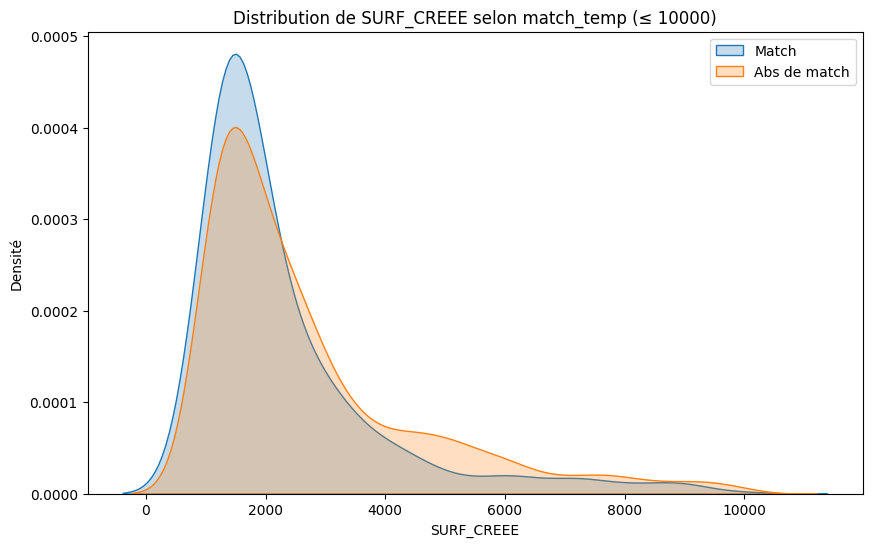

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
ann=2022

# Filtrer SURF_CREEE <= 5000
matched = temp_sit[temp_sit["match_temp"].notna() & (temp_sit["match_temp"] >= 0) & (temp_sit["SURF_CREEE"] <= 10000) & (temp_sit["ANNEE_REELLE_AUTORISATION"]==ann)]
unmatched = temp_sit[(temp_sit["match_temp"].isna() | (temp_sit["match_temp"] < 0)) & (temp_sit["SURF_CREEE"] <= 10000) & (temp_sit["ANNEE_REELLE_AUTORISATION"]==ann)]

plt.figure(figsize=(10,6))

sns.kdeplot(matched["SURF_CREEE"].dropna(), label="Match", fill=True)
sns.kdeplot(unmatched["SURF_CREEE"].dropna(), label="Abs de match", fill=True)

plt.xlabel("SURF_CREEE")
plt.ylabel("Densité")
plt.title("Distribution de SURF_CREEE selon match_temp (≤ 10000)")
plt.legend()
plt.show()



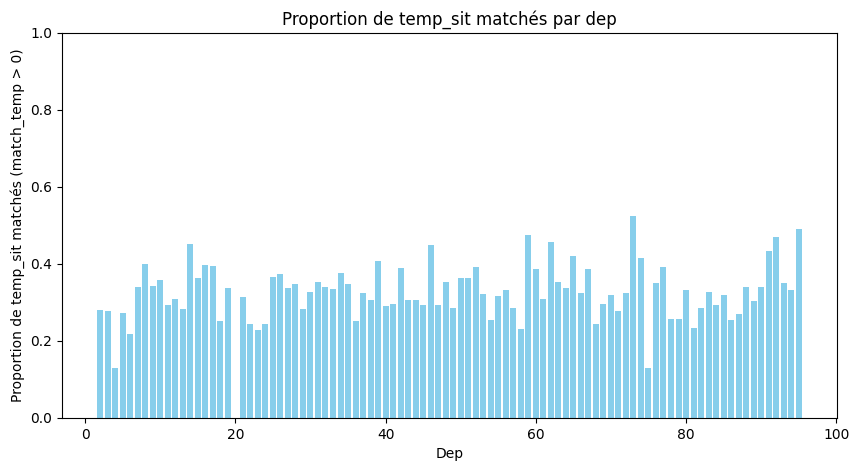

In [89]:
import matplotlib.pyplot as plt

# On récupère les années présentes
deps = sorted(temp_sit['DEP_CODE'].dropna().unique())

# Calculer la proportion de match pour chaque année
proportions = []
for dep in deps:
    subset = temp_sit[temp_sit['DEP_CODE'] == dep]
    if len(subset) == 0:
        proportions.append(0)
    else:
        prop = (subset['match_temp'] > 0).sum() / len(subset)
        proportions.append(prop)

# Plot
plt.figure(figsize=(10,5))
plt.bar(deps, proportions, color='skyblue')
plt.xlabel('Dep')
plt.ylabel('Proportion de temp_sit matchés (match_temp > 0)')
plt.title('Proportion de temp_sit matchés par dep')
plt.ylim(0, 1)
plt.show()


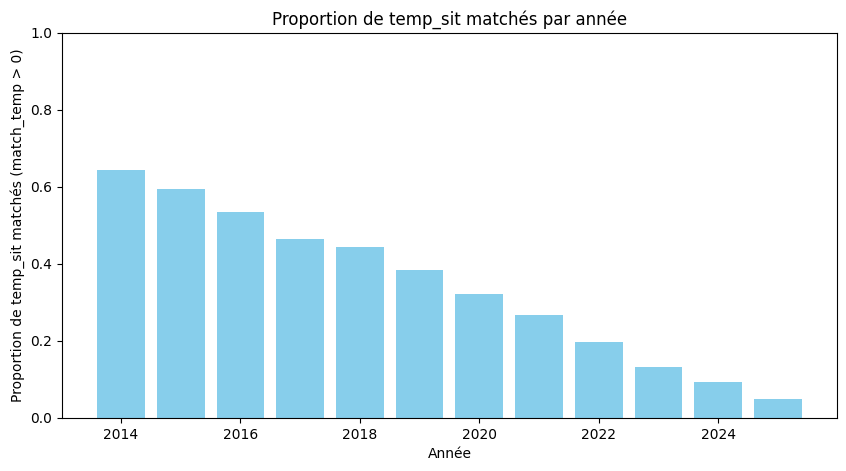

In [90]:
import matplotlib.pyplot as plt

# On récupère les années présentes
annees = sorted(temp_sit['ANNEE_REELLE_AUTORISATION'].dropna().unique())

# Calculer la proportion de match pour chaque année
proportions = []
for annee in annees:
    subset = temp_sit[temp_sit['ANNEE_REELLE_AUTORISATION'] == annee]
    if len(subset) == 0:
        proportions.append(0)
    else:
        prop = (subset['match_temp'] > 0).sum() / len(subset)
        proportions.append(prop)

# Plot
plt.figure(figsize=(10,5))
plt.bar(annees, proportions, color='skyblue')
plt.xlabel('Année')
plt.ylabel('Proportion de temp_sit matchés (match_temp > 0)')
plt.title('Proportion de temp_sit matchés par année')
plt.ylim(0, 1)
plt.show()


In [92]:
temp_sit["SURF_CREEE"].mean()

np.float64(4536.782437502322)

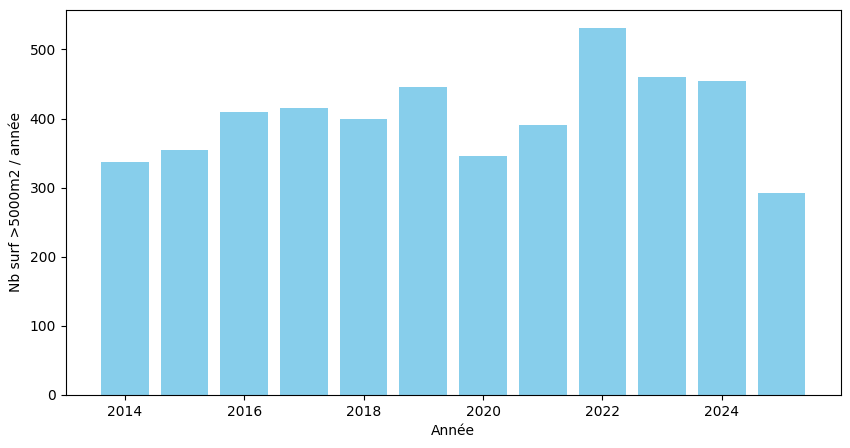

In [103]:
import matplotlib.pyplot as plt

# On récupère les années présentes
annees = sorted(temp_sit['ANNEE_REELLE_AUTORISATION'].dropna().unique())

# Calculer la proportion de match pour chaque année
surface_moy = []
for annee in annees:
    subset = temp_sit[temp_sit['ANNEE_REELLE_AUTORISATION'] == annee]
    surf =(subset["SURF_CREEE"]>5000).sum()
    surface_moy.append(surf)

# Plot
plt.figure(figsize=(10,5))
plt.bar(annees, surface_moy, color='skyblue')
plt.xlabel('Année')
plt.ylabel('Nb surf >5000m2 / année')
plt.title('')
plt.show()
